# Technology focus: Xenium

This notebook will present an overview of the plotting functionalities of the `spatialdata` framework, in the context of a Xenium dataset.

Other notebooks, focused on data manipualtion, are also available for Xenium data:
- Alignment of a Xenium and Visium datasets (this is one of the reproducibility notebooks for the analysis of our paper) [notebook](https://github.com/scverse/spatialdata-notebooks/blob/main/notebooks/paper_reproducibility/00_xenium_and_visium.ipynb)
- Workflow showing saving annotations in Xenium Explorer and accessing them in SpaitalData, and viceversa [notebook](https://github.com/quentinblampey/spatialdata_xenium_explorer/blob/master/docs/10x_tutorials/xenium/xenium_tuto.ipynb). Tutorial from Quentin Blampey.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

## Loading the data

A reader for Xenium data is available in `spatialdata-io`. We used it to parse and convert to Zarr a [Xenium dataset of Human Lung Cancer](https://www.10xgenomics.com/datasets/preview-data-ffpe-human-lung-cancer-with-xenium-multimodal-cell-segmentation-1-standard).

Information regarding data licensing and attribution for the dataset listed above is also available at: https://github.com/scverse/spatialdata-notebooks/tree/main/datasets.

You can download the data from the link above, or from this [convenience python script](https://github.com/giovp/spatialdata-sandbox/blob/main/xenium_2.0.0_io/download.py) and convert it to spatialdata format with [this script](https://github.com/giovp/spatialdata-sandbox/blob/main/xenium_2.0.0_io/to_zarr.py), rename the `.zarr` store to `xenium.zarr` and place it in the current folder (in alternatively you can use symlinks to make the data visible).

The dataset used in this notebook is the latest Xenium Multimodal Cell Segmentation extension of the Xenium technology, available for data processed using Xenium Analyzer version 2.0.0 and when Cell Segmentation Kit was used. Nevertheless, the `xenium()` reader supports all the Xenium versions.

In [2]:
xenium_path = "./xenium_2.0.0.zarr"

In [3]:
%%time
import spatialdata as sd
import spatialdata_plot  # noqa: F401

sdata = sd.read_zarr(xenium_path)
sdata

CPU times: user 2.38 s, sys: 518 ms, total: 2.89 s
Wall time: 3.59 s


/opt/miniconda3/envs/ome/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


SpatialData object, with associated Zarr store: /Users/macbook/embl/projects/basel/spatialdata-sandbox/xenium_2.0.0_io/data.zarr
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 45087, 11580), (3, 22543, 5790), (3, 11271, 2895), (3, 5635, 1447), (3, 2817, 723)
│     └── 'morphology_focus': DataTree[cyx] (5, 17098, 51187), (5, 8549, 25593), (5, 4274, 12796), (5, 2137, 6398), (5, 1068, 3199)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (17098, 51187), (8549, 25593), (4274, 12796), (2137, 6398), (1068, 3199)
│     └── 'nucleus_labels': DataTree[yx] (17098, 51187), (8549, 25593), (4274, 12796), (2137, 6398), (1068, 3199)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (162254, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (162254, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (156628, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (162254, 377)
w

The datasets contains 2 large microscopy image, represented as a multiscale, chunked image; the first one, `he_image` is the H&E image of the tissue, stained post-Xenium measurement, and the `morphology_focus` image which consists of the image of the tissue used for the Xenium experiment.

Furthermore, it also contains label images, that are the segmentation masks of cells or nuclei (`cell_labels` and `nucleus_labels` respectively).

## Plotting the images

Let's visualize the images.

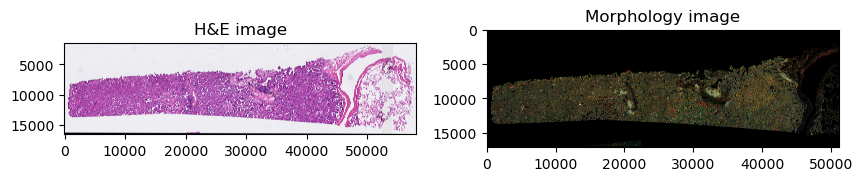

In [4]:
import matplotlib.pyplot as plt

axes = plt.subplots(1, 2, figsize=(10, 10))[1].flatten()
sdata.pl.render_images("he_image").pl.show(ax=axes[0], title="H&E image")
sdata.pl.render_images("morphology_focus").pl.show(ax=axes[1], title="Morphology image")

We can also crop and visualize a smaller region to appreciate morphological differences measured by the two modalities, together with the cell segmentation mask. Spatial cropping is introduced in a dedicated notebook in the documentation.

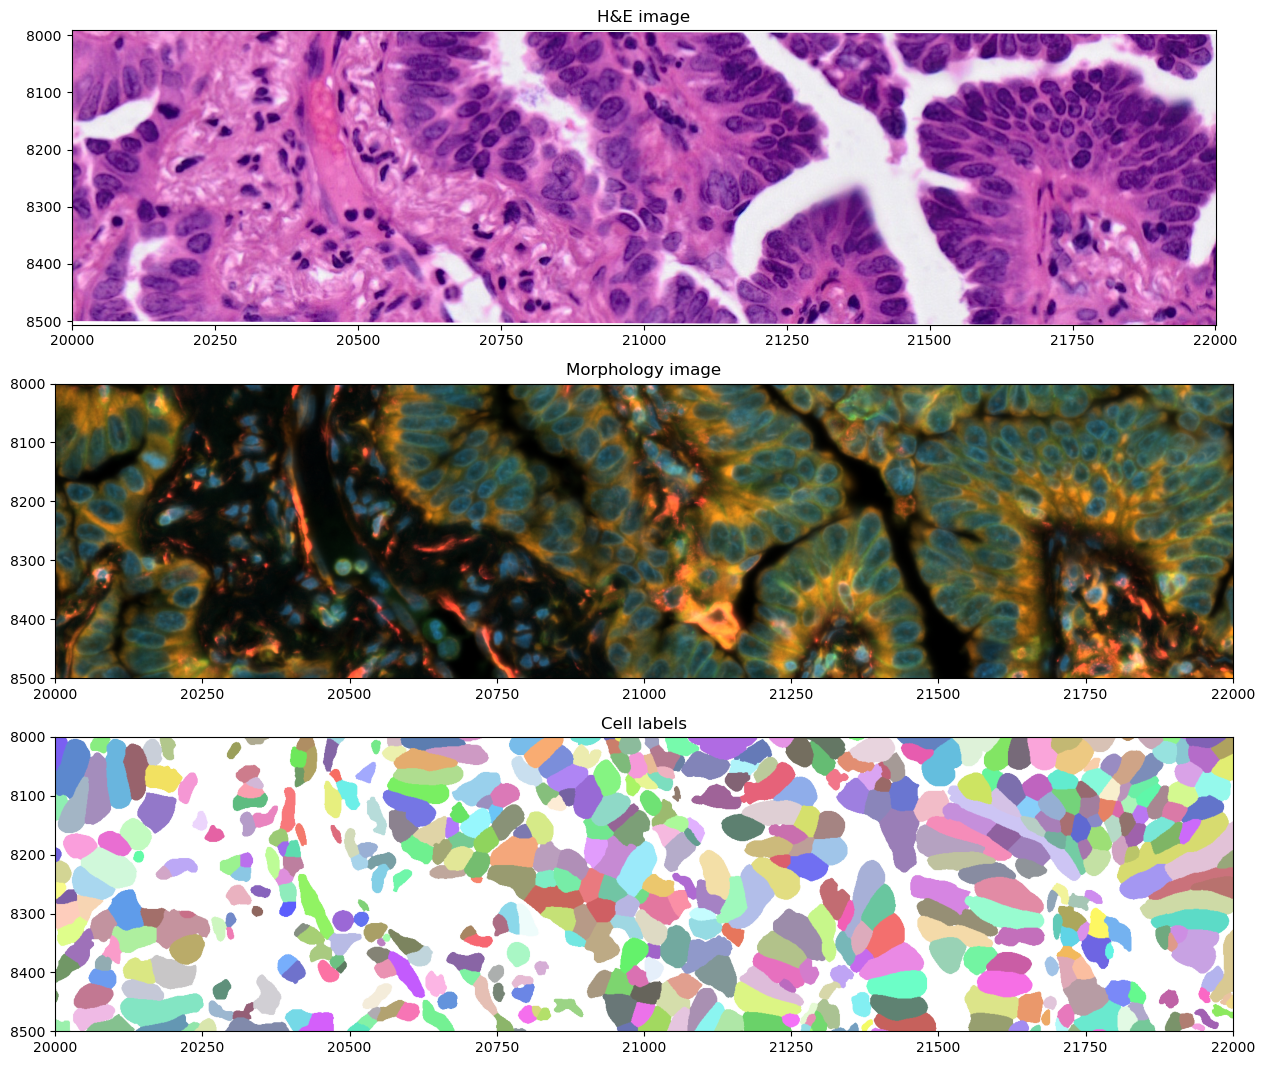

In [5]:
from spatialdata import bounding_box_query

axes = plt.subplots(3, 1, figsize=(20, 13))[1].flatten()


def crop0(x):
    return bounding_box_query(
        x,
        min_coordinate=[20_000, 8000],
        max_coordinate=[22_000, 8500],
        axes=("x", "y"),
        target_coordinate_system="global",
    )


crop0(sdata).pl.render_images("he_image").pl.show(ax=axes[0], title="H&E image", coordinate_systems="global")
crop0(sdata).pl.render_images("morphology_focus").pl.show(
    ax=axes[1], title="Morphology image", coordinate_systems="global"
)
crop0(sdata).pl.render_labels("cell_labels").pl.show(ax=axes[2], title="Cell labels", coordinate_systems="global")

## Exploring the multimodal segmentation

Let's visualize the 4 channels that are used, for this dataset, for computing the cell segmentation. This is specific for datasets profiled using the Cell Segmentation Kit and processed with the Xenium Analyzer >= 2.0.0.

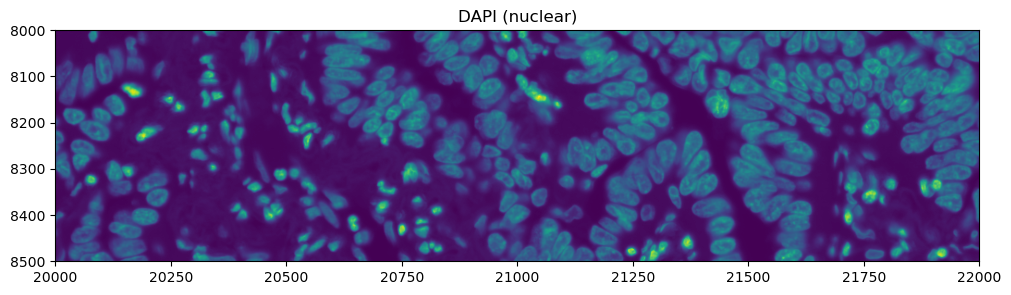

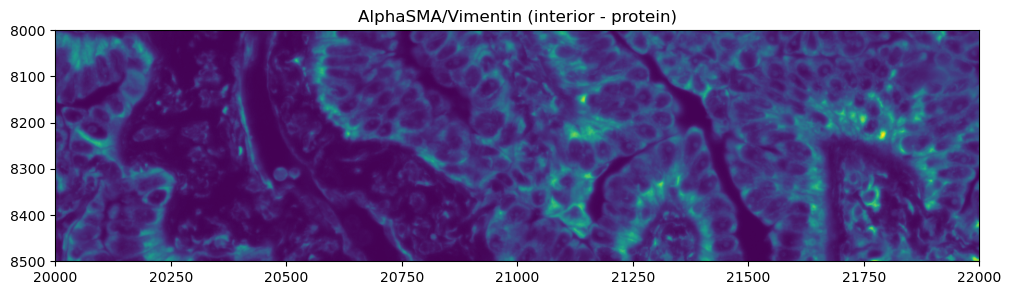

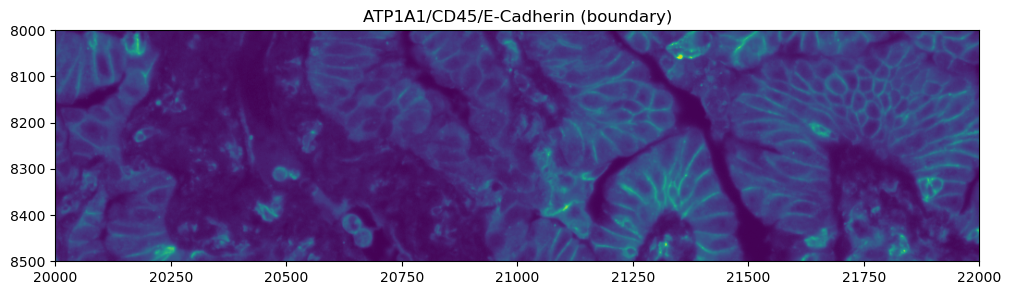

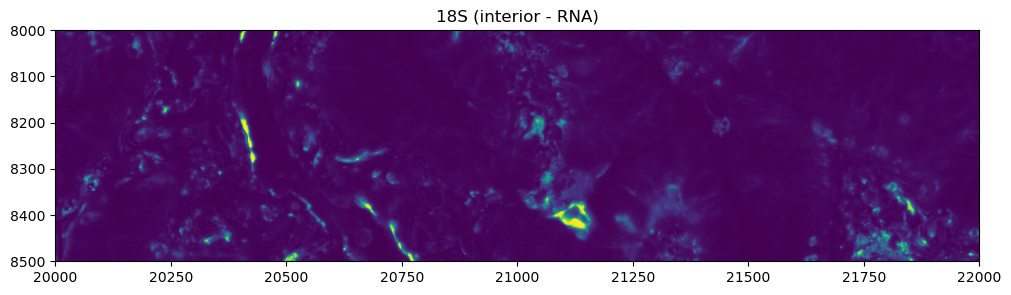

In [6]:
crop0(sdata).pl.render_images("morphology_focus", channel=0).pl.show(title="DAPI (nuclear)", figsize=(10, 10))
crop0(sdata).pl.render_images("morphology_focus", channel=1).pl.show(
    title="AlphaSMA/Vimentin (interior - protein)", figsize=(10, 10)
)
crop0(sdata).pl.render_images("morphology_focus", channel=2).pl.show(
    title="ATP1A1/CD45/E-Cadherin (boundary)", figsize=(10, 10)
)
crop0(sdata).pl.render_images("morphology_focus", channel=3).pl.show(title="18S (interior - RNA)", figsize=(10, 10))

## Plotting the gene expression data

With SpatialData we can also plot gene expression data on top of the images. We can plot the expression of a single gene, or the expression of multiple genes.
To showcase different functionalities, we will use the `cell_circles` Shapes element to overlay gene expression over the image, instead of the raster labels showed above.

Let's first normalize and select highly variable genes.

In [7]:
import scanpy as sc

sc.pp.normalize_total(sdata.tables["table"])
sc.pp.log1p(sdata.tables["table"])
sc.pp.highly_variable_genes(sdata.tables["table"])
sdata.tables["table"].var.sort_values("means")

/opt/miniconda3/envs/ome/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:233: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


,gene_ids,feature_types,genome,highly_variable,means,dispersions,dispersions_norm
UMOD,ENSG00000169344,Gene Expression,Unknown,False,0.000855,0.733388,0.142545
LY6D,ENSG00000167656,Gene Expression,Unknown,False,0.001364,0.557849,-0.404188
SST,ENSG00000157005,Gene Expression,Unknown,False,0.001424,0.184340,-1.567515
TCF15,ENSG00000125878,Gene Expression,Unknown,False,0.001587,0.189523,-1.551373
CCL27,ENSG00000213927,Gene Expression,Unknown,False,0.001663,0.526737,-0.501089
...,...,...,...,...,...,...,...
CAPN8,ENSG00000203697,Gene Expression,Unknown,True,0.859493,1.032884,1.000000
EPCAM,ENSG00000119888,Gene Expression,Unknown,False,0.897788,0.938736,-0.707107
TCIM,ENSG00000176907,Gene Expression,Unknown,True,0.948361,1.136240,0.707107
CYP2B6,ENSG00000197408,Gene Expression,Unknown,True,0.989477,1.524039,1.000000


INFO     Using matplotlib                                                                                          


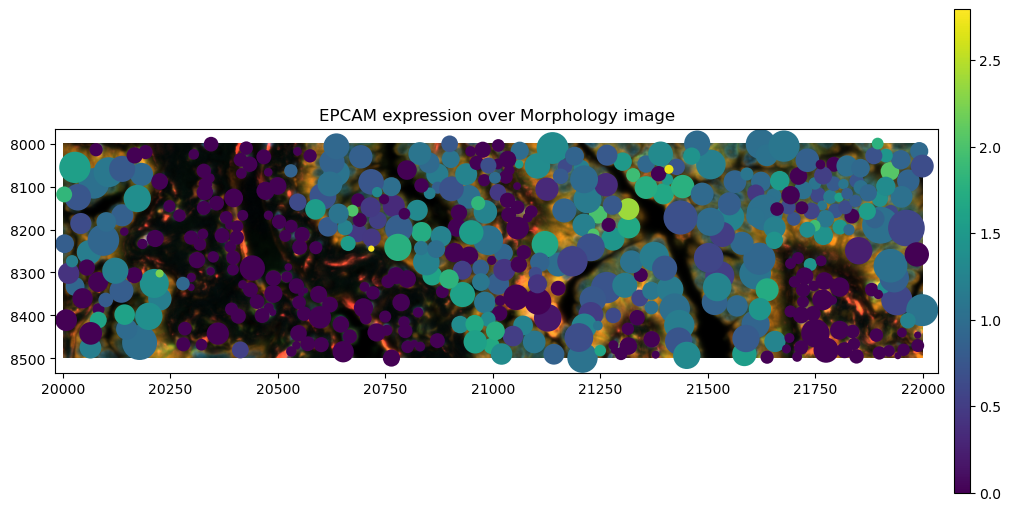

In [8]:
gene_name = "EPCAM"
crop0(sdata).pl.render_images("morphology_focus").pl.render_shapes(
    "cell_circles",
    color=gene_name,
).pl.show(title=f"{gene_name} expression over Morphology image", coordinate_systems="global", figsize=(10, 5))

We can also assign the table to a different region, in order to overlay the gene expression for the specified region.
SpatialData stores the information of which region is the table in the following places:
- in `sdata.tables[<table_name>].uns["spatialdata_attrs]["region"]` it stores the regions that the table is annotating.
- The name of the region is stored under `sdata.tables[<table_name>].obs["region_key"]`.

We can use a utility function to modify that information, and hence plot the gene expression for a different shapes.

/Users/macbook/embl/projects/basel/spatialdata/src/spatialdata/_core/spatialdata.py:480: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     Using matplotlib                                                                                          


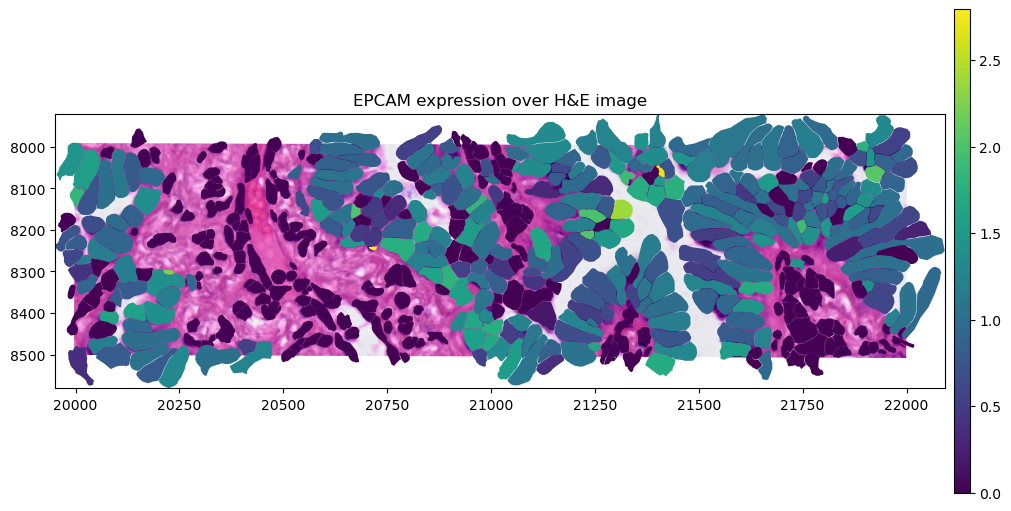

In [9]:
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

crop0(sdata).pl.render_images("he_image").pl.render_shapes(
    "cell_boundaries",
    color=gene_name,
).pl.show(title=f"{gene_name} expression over H&E image", coordinate_systems="global", figsize=(10, 5))

Finally, we can also plot transcript locations, together with the same layers selected as before.

INFO     Using matplotlib                                                                                          


/opt/miniconda3/envs/ome/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/opt/miniconda3/envs/ome/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/macbook/embl/projects/basel/spatialdata/src/spatialdata/_core/_elements.py:106: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/macbook/embl/projects/basel/spatialdata-plot/src/spatialdata_plot/pl/utils.py:720: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/Users

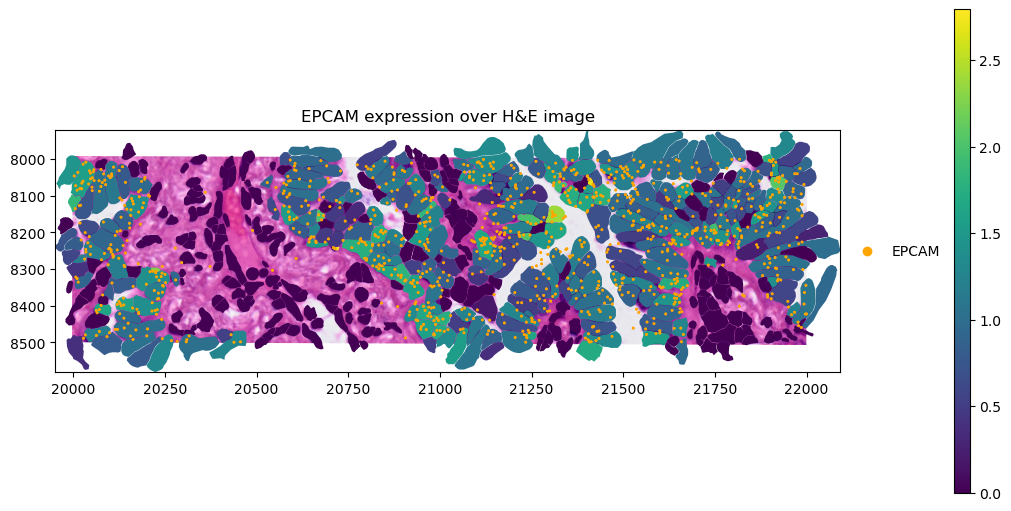

In [10]:
crop0(sdata).pl.render_images("he_image").pl.render_shapes(
    "cell_boundaries",
    color=gene_name,
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=gene_name,
    palette="orange",
).pl.show(title=f"{gene_name} expression over H&E image", coordinate_systems="global", figsize=(10, 5))